In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st

In [49]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

/tmp/ipykernel_1456/1225836767.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


In [50]:
trades.info()
trades.isnull().sum()

sentiment.info()
sentiment.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83805 entries, 0 to 83804
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           83805 non-null  object 
 1   Coin              83805 non-null  object 
 2   Execution Price   83805 non-null  float64
 3   Size Tokens       83805 non-null  float64
 4   Size USD          83805 non-null  float64
 5   Side              83805 non-null  object 
 6   Timestamp IST     83805 non-null  object 
 7   Start Position    83805 non-null  float64
 8   Direction         83805 non-null  object 
 9   Closed PnL        83805 non-null  float64
 10  Transaction Hash  83805 non-null  object 
 11  Order ID          83804 non-null  float64
 12  Crossed           83804 non-null  object 
 13  Fee               83804 non-null  float64
 14  Trade ID          83804 non-null  float64
 15  Timestamp         83804 non-null  float64
dtypes: float64(9), object(7)
memory usage: 1

,0
timestamp,0
value,0
classification,0
date,0


In [51]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format="%d-%m-%Y %H:%M")
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [52]:
trades['Date'] = trades['Timestamp IST'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

In [53]:
trades['Date'] = trades['Timestamp IST'].dt.date
merged = trades.merge(
    sentiment,
    on='Date',
    how='left'
)

In [54]:
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,87.435908
Extreme Greed,155.321507
Fear,82.165231
Greed,79.745256
Neutral,71.849143


In [55]:
merged.groupby('classification')['Closed PnL'].sum()

,Closed PnL
classification,
Extreme Fear,6.270903e+05
Extreme Greed,1.663649e+06
Fear,2.497905e+06
Greed,1.561970e+06
Neutral,1.144413e+06


In [56]:
merged.groupby('classification')['Size Tokens'].mean()

,Size Tokens
classification,
Extreme Fear,3806.311379
Extreme Greed,25681.276959
Fear,4456.625490
Greed,7181.275862
Neutral,5989.596051


In [57]:
merged['win'] = merged['Closed PnL'] > 0

In [58]:
merged.groupby('classification')['win'].mean()*100

,win
classification,
Extreme Fear,38.022867
Extreme Greed,53.860517
Fear,45.791257
Greed,40.286925
Neutral,46.534405


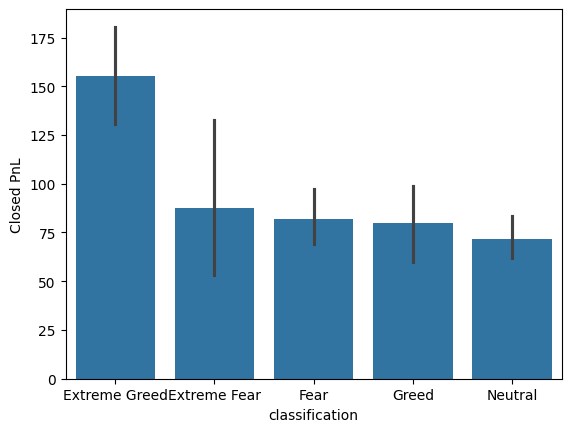

In [59]:
sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)
plt.show()

## Insight

The average profit per trade is highest during Greed periods.

This indicates that bullish market conditions create more profitable trading opportunities. Positive market sentiment often results in stronger price momentum, allowing traders to capture larger gains.

### Key Takeaway
Market sentiment has a direct influence on trader profitability, with Greed conditions producing the best average performance.

<Axes: xlabel='classification'>

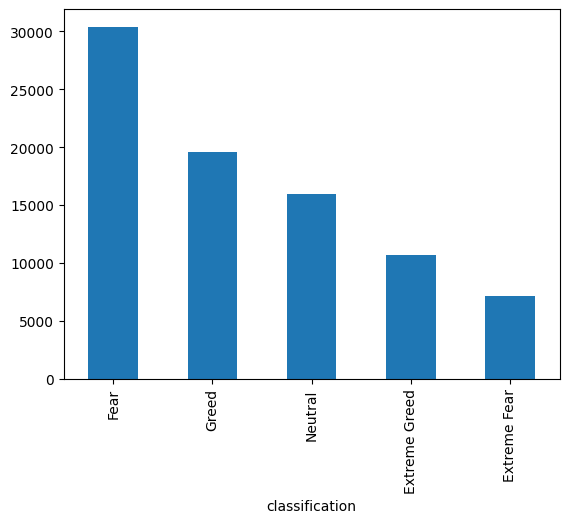

In [60]:
merged['classification'].value_counts().plot(kind='bar')

## Insight

Fear periods generated the highest overall profit.

Although average profitability is higher during Greed periods, the large number of trades executed during Fear conditions contributed to higher cumulative profits.

### Key Takeaway
Market volatility during Fear periods attracts more trading activity and creates more opportunities for profit generation.

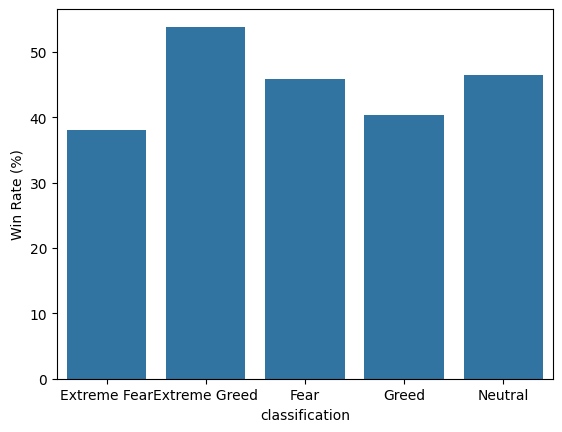

In [61]:
win_rate = (
    merged.groupby('classification')['win']
    .mean()*100
).reset_index()

sns.barplot(data=win_rate,
            x='classification',
            y='win')

plt.ylabel("Win Rate (%)")
plt.show()

## Insight

Extreme Greed periods show the highest percentage of profitable trades.

Strong bullish momentum appears to increase the likelihood of successful trades compared to other market conditions.

### Key Takeaway
Sentiment can serve as a useful indicator for identifying favorable trading environments.

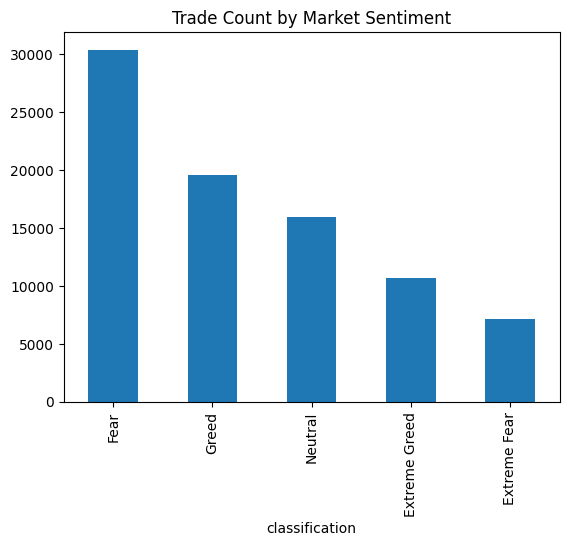

In [62]:
trade_count = merged['classification'].value_counts()

trade_count.plot(kind='bar')
plt.title("Trade Count by Market Sentiment")
plt.show()

## Insight

The majority of trades occurred during Fear periods.

This suggests that traders become more active when markets are uncertain or volatile, leading to increased trading volume.

### Key Takeaway
Fear-driven markets encourage greater participation and create more trading opportunities.

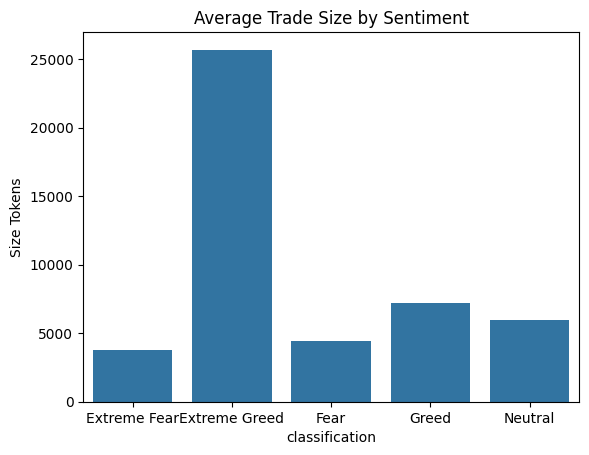

In [63]:
trade_size = merged.groupby('classification')['Size Tokens'].mean().reset_index()

sns.barplot(data=trade_size,
            x='classification',
            y='Size Tokens')

plt.title("Average Trade Size by Sentiment")
plt.show()

## Insight

Trade sizes increase significantly during Fear and Extreme Greed periods.

This indicates that traders take larger positions when emotions dominate market behavior, reflecting higher confidence and risk appetite.

### Key Takeaway
Extreme market sentiment influences not only trading frequency but also position sizing decisions.

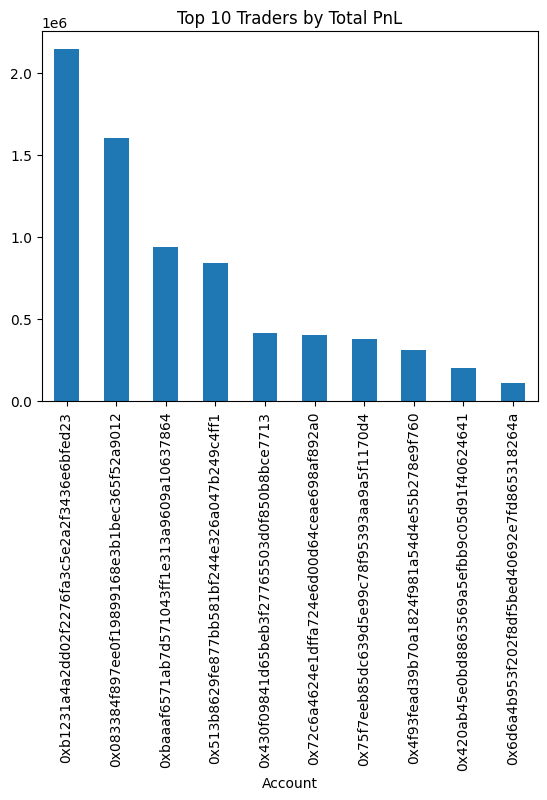

In [64]:
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_traders.plot(kind='bar')
plt.title("Top 10 Traders by Total PnL")
plt.show()

## Insight

A small number of traders account for a significant portion of total profits.

This suggests that successful trading performance is concentrated among a limited group of highly effective participants.

### Key Takeaway
Analyzing the behavior of top-performing traders may reveal profitable strategies and risk-management techniques.

# Conclusion

This analysis demonstrates a clear relationship between Bitcoin market sentiment and trader behavior.

Key findings include:

- Greed periods generate the highest average profitability.
- Fear periods account for the largest trading activity and total profits.
- Extreme Greed conditions produce the highest win rates.
- Traders increase position sizes during emotionally charged market conditions.

These findings suggest that sentiment indicators can be incorporated into trading strategies to improve decision-making, position sizing, and risk management.